# Convergence of the mean-width estimator

Loads the JSON produced by `scripts/run_convergence.py` and plots:
1. Mean width ± 1 std vs N
2. Std vs N on log-log (expected slope: −½)
3. Coefficient of variation (%) vs N

In [58]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ── Change this path to match your run ──────────────────────────────────────
RESULTS_PATH = "../results/convergence/convergence_sample42_bits4.json"
# ────────────────────────────────────────────────────────────────────────────

In [59]:
with open(RESULTS_PATH) as f:
    data = json.load(f)

N_grid  = data["n_directions_grid"]
raw     = data["results"]

# JSON keys are strings; cast back to int for sorting
means = np.array([raw[str(N)]["mean"] for N in N_grid])
stds  = np.array([raw[str(N)]["std"]  for N in N_grid])
cvs   = stds / means * 100   # coefficient of variation (%)

print(f"Sample idx   : {data['sample_idx']}")
print(f"Bits         : {data['bits']}")
print(f"Replications : {data['n_replications']}")
print(f"N grid       : {N_grid}")
print()
print(f"{'N':>6}  {'mean':>10}  {'std':>8}  {'CV %':>7}")
print("-" * 38)
for N, m, s, cv in zip(N_grid, means, stds, cvs):
    print(f"{N:>6}  {m:>10.4f}  {s:>8.4f}  {cv:>7.2f}")

Sample idx   : 42
Bits         : 4
Replications : 20
N grid       : [10, 20, 30, 50, 75, 100, 150, 200, 300]

     N        mean       std     CV %
--------------------------------------
    10     37.1842    0.1319     0.35
    20     37.1236    0.0938     0.25
    30     37.1510    0.0609     0.16
    50     37.1448    0.0617     0.17
    75     37.1333    0.0478     0.13
   100     37.1374    0.0283     0.08
   150     37.1523    0.0294     0.08
   200     37.1420    0.0196     0.05
   300     37.1394    0.0182     0.05


Plot saved to ../results/convergence/convergence_sample42_bits4_plot.pdf


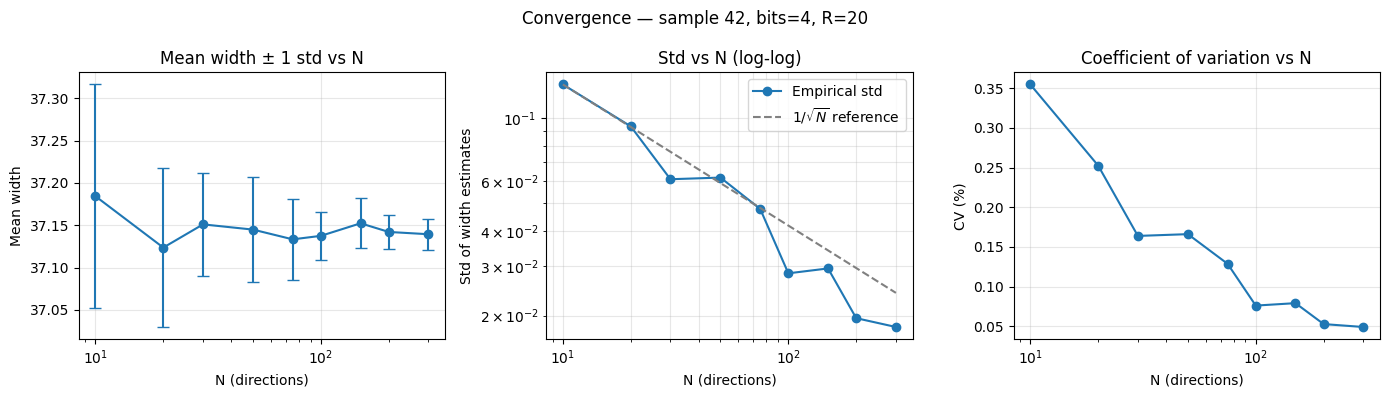

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
N_arr = np.array(N_grid, dtype=float)

# ── Panel 1: mean width ± 1 std vs N ────────────────────────────────────────
ax = axes[0]
ax.errorbar(N_grid, means, yerr=stds, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("N (directions)")
ax.set_ylabel("Mean width")
ax.set_title("Mean width ± 1 std vs N")
ax.grid(True, alpha=0.3)

# ── Panel 2: std vs N log-log with 1/√N reference ───────────────────────────
ax = axes[1]
ax.loglog(N_grid, stds, "o-", label="Empirical std")
scale = stds[0] * np.sqrt(N_arr[0])
ax.loglog(N_grid, scale / np.sqrt(N_arr), "--", color="gray", label=r"$1/\sqrt{N}$ reference")
ax.set_xlabel("N (directions)")
ax.set_ylabel("Std of width estimates")
ax.set_title("Std vs N (log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# ── Panel 3: coefficient of variation vs N ───────────────────────────────────
ax = axes[2]
ax.plot(N_grid, cvs, "o-")
ax.set_xscale("log")
ax.set_xlabel("N (directions)")
ax.set_ylabel("CV (%)")
ax.set_title("Coefficient of variation vs N")
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Convergence — sample {data['sample_idx']}, bits={data['bits']}, R={data['n_replications']}",
    fontsize=12,
)
plt.tight_layout()

out_path = RESULTS_PATH.replace(".json", "_plot.pdf")
plt.savefig(out_path, bbox_inches="tight")
print(f"Plot saved to {out_path}")
plt.show()

In [ ]:
def plot_convergence(data_id):

    RESULTS_PATH = f"../results/convergence/convergence_sample{data_id}_bits4.json"
    
    with open(RESULTS_PATH) as f:
        data = json.load(f)

    N_grid  = data["n_directions_grid"]
    raw     = data["results"]

    # JSON keys are strings; cast back to int for sorting
    means = np.array([raw[str(N)]["mean"] for N in N_grid])
    stds  = np.array([raw[str(N)]["std"]  for N in N_grid])
    print(means)
    print(stds)
    # cvs   = stds / means * 100   # coefficient of variation (%)


    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    N_arr = np.array(N_grid, dtype=float)

    ax.errorbar(N_grid, means, yerr=stds, fmt="o-", capsize=4)
    # ax.set_xscale("log")
    ax.set_xlabel("Number of directions")
    ax.set_ylabel("Polytope volume (eestimate)")
    ax.set_title(f"Sample {data_id}")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    out_path = RESULTS_PATH.replace(".json", "_plot.pdf")
    plt.savefig(out_path, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()

[38.39355226 38.38828353 38.41248692 38.38011901 38.39457403 38.38458213
 38.40601071 38.39175956 38.40123308]
[0.11558496 0.05966487 0.07403655 0.0532017  0.05737606 0.05118977
 0.02978601 0.03539735 0.02587411]
Plot saved to ../results/convergence/convergence_sample47_bits4_plot.pdf


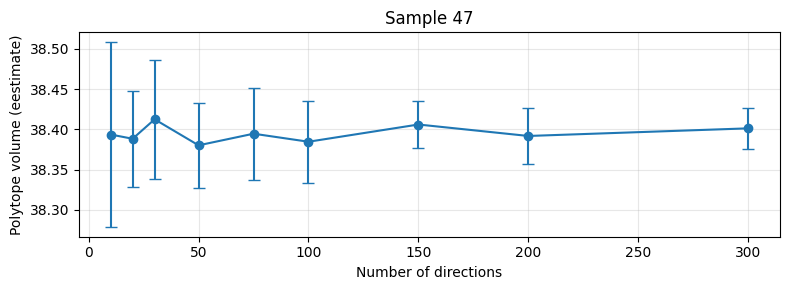

In [ ]:
for data_id in range(50):

    plot_convergence(data_id)